### **Imports des librairies**

In [77]:
from typing import (
    Any,
    Tuple)
from collections.abc import Iterator
from pathlib import Path

import math
import random

from sklearn.base import (
    TransformerMixin,
    ClassifierMixin)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    FunctionTransformer,
    MinMaxScaler,
    StandardScaler,
    OneHotEncoder,
    PowerTransformer)
from sklearn.compose import (
    ColumnTransformer,
    make_column_transformer)
from sklearn.pipeline import (
    Pipeline,
    make_pipeline)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate)
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay)
from sklearn.calibration import (
    calibration_curve,
    CalibrationDisplay)
from sklearn.linear_model import LogisticRegression

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### **Sélection d'une seed fixe**

In [78]:
rand_seed: int = 42

random.seed(rand_seed)

### **Chargement du dataset**

In [79]:
df_file: str = r"..\Dataset\Student Depression Dataset\Dataset.csv"

df_ori: pd.DataFrame = pd.read_csv(filepath_or_buffer=df_file)

### **Vue d'ensemble du dataset**

In [80]:
df_ori.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27898.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139867,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437347,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


In [81]:
df_ori.info()

<class 'pandas.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  str    
 2   Age                                    27901 non-null  int64  
 3   City                                   27901 non-null  str    
 4   Profession                             27901 non-null  str    
 5   Academic Pressure                      27901 non-null  int64  
 6   Work Pressure                          27901 non-null  int64  
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  int64  
 9   Job Satisfaction                       27901 non-null  int64  
 10  Sleep Duration                         27901 non-null  str    
 11  Dietary Habit

In [82]:
display("Nombre de valeurs nulles")
display(df_ori.isna().sum())
print("\n" * 2)

display("Nombre de doublons purs")
display(df_ori.duplicated().sum())
print("\n" * 2)

'Nombre de valeurs nulles'

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         3
Family History of Mental Illness         0
Depression                               0
dtype: int64

'Nombre de doublons purs'

np.int64(0)

In [83]:
series_target_val_count: pd.Series = df_ori["Depression"].value_counts()
target_val_count_false: int = series_target_val_count[0]
target_val_count_true: int = series_target_val_count[1]
ratio_target_false_true: float = target_val_count_false / target_val_count_true

print("target_false_count\n\t", target_val_count_false)
print("target_true_count\n\t", target_val_count_true)
print("ratio_target_false_true\n\t", ratio_target_false_true)

target_false_count
	 11565
target_true_count
	 16336
ratio_target_false_true
	 0.7079456415279138


### **Transformation du dataset**

In [84]:
df : pd.DataFrame = pd.DataFrame(columns = list(df_ori.columns) + ["professionPressure", "professionSatisfaction"])

#### ***Suppression des lignes dont la "profession" n'est pas "Student"***

In [85]:
count : int = 0
for row_idx in range(len(df_ori[0:100])):
# for row_idx in range(len(df_ori)):
    row_data : pd.Series = df_ori.iloc[row_idx]
    
    if (row_data["Profession"] == "Student"):
        df = pd.concat([df, pd.DataFrame([row_data])],
                       ignore_index = True)
        # count += 1
        # if (count >= 5):
        #     break

display(df)

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,professionPressure,professionSatisfaction
0,2,Male,33,Visakhapatnam,Student,5,0,8.97,2,0,5-6 hours,Healthy,B.Pharm,Yes,3,1.0,No,1,NaN,NaN
1,8,Female,24,Bangalore,Student,2,0,5.9,5,0,5-6 hours,Moderate,BSc,No,3,2.0,Yes,0,NaN,NaN
2,26,Male,31,Srinagar,Student,3,0,7.03,5,0,Less than 5 hours,Healthy,BA,No,9,1.0,Yes,0,NaN,NaN
3,30,Female,28,Varanasi,Student,3,0,5.59,2,0,7-8 hours,Moderate,BCA,Yes,4,5.0,Yes,1,NaN,NaN
4,32,Female,25,Jaipur,Student,4,0,8.13,3,0,5-6 hours,Moderate,M.Tech,Yes,1,1.0,No,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,525,Female,34,Hyderabad,Student,3,0,5.32,3,0,7-8 hours,Unhealthy,B.Tech,Yes,7,4.0,Yes,1,NaN,NaN
96,529,Male,22,Nagpur,Student,4,0,6.27,4,0,5-6 hours,Moderate,B.Com,Yes,10,3.0,No,1,NaN,NaN
97,530,Male,23,Lucknow,Student,3,0,7.7,2,0,More than 8 hours,Unhealthy,M.Com,No,11,3.0,Yes,0,NaN,NaN
98,534,Male,24,Kalyan,Student,3,0,9.66,1,0,Less than 5 hours,Healthy,M.Pharm,Yes,9,1.0,Yes,1,NaN,NaN


#### ***Fusion de colonnes aux sémantiques semblables***

In [86]:
# for row_idx in range(len(df)):
#     df_row : pd.Series = df.iloc[row_idx]

#     # Fusion des colonnes 'Academic Pressure' et 'Work Pressure' (afin de créer une colonne "générique" exprimant une idée semblable)
#     key_ori_pressure : str = ""
#     if (df_row["Profession"] == "Student"):
#         key_ori_pressure = df["Academic Pressure"]
#     else:
#         key_ori_pressure = df["Work Pressure"]

#     # Fusion des colonnes 'Study Satisfaction' et 'Job Satisfaction' (afin de créer une colonne "générique" exprimant une idée semblable)
#     key_ori_satisfaction : str = ""
#     if (df_row["Profession"] == "Student"):
#         key_ori_satisfaction = df["Study Satisfaction"]
#     else:
#         key_ori_satisfaction = df["Job Satisfaction"]

#     df.iloc[row_idx] = df_row



for row_idx in range(len(df)):
    df_row : pd.Series = df.iloc[row_idx]

    # Fusion des colonnes 'Academic Pressure' et 'Work Pressure' (afin de créer une colonne "générique" exprimant une idée semblable)*
    if (df_row["Profession"] == "Student"):
        df_row["professionPressure"] = df_row["Academic Pressure"]
    else:
        df_row["professionPressure"] = df_row["Work Pressure"]

    # Fusion des colonnes 'Study Satisfaction' et 'Job Satisfaction' (afin de créer une colonne "générique" exprimant une idée semblable)
    if (df_row["Profession"] == "Student"):
        df_row["professionSatisfaction"] = df_row["Study Satisfaction"]
    else:
        df_row["professionSatisfaction"] = df_row["Job Satisfaction"]

    df.iloc[row_idx] = df_row


df = df.drop(["id", "Academic Pressure", "Work Pressure", "Study Satisfaction", "Job Satisfaction"],
            axis = "columns")

### **Colonnes : changements de noms et réorganisation**

In [87]:
map_column_name : dict = {
    "Gender" : "gender",
    "Age" : "age",
    "City" : "city",
    "Profession" : "profession",
    "CGPA" : "cgpa",
    "Sleep Duration" : "sleep_duration",
    "Dietary Habits" : "dietary_habits",
    "Degree" : "degree",
    "Have you ever had suicidal thoughts ?" : "history_thoughts_suicidal",
    "Work/Study Hours" : "profession_hour_daily",
    "Financial Stress" : "financial_stress",
    "Family History of Mental Illness" : "history_family_illness_mental",
    "Depression" : "depression",
    "professionPressure" : "profession_pressure",
    "professionSatisfaction" : "profession_satisfaction"
}

df = df.rename(columns = map_column_name)

df = df.iloc[:, [0, 1, 2, 4, 7, 3, 9, 13, 14, 10, 5, 6, 11, 8, 12]]

In [88]:
# ll = [
#     "gender",
#     "age",
#     "city", 
#     "cgpa",
#     "degree", 
#     "profession",     
#     "profession_hour_daily",
#     "profession_pressure",     
#     "profession_satisfaction",         
#     "financial_stress",       
#     "sleep_duration",    
#     "dietary_habits",  
#     "history_family_illness_mental",  
#     "history_thoughts_suicidal",    
#     "depression" ]

# for col_idx in range(len(df.columns)):
#     print(f"[{df.columns[col_idx] == ll[col_idx]}] {df.columns[col_idx]} : {ll[col_idx]}")

In [89]:
display(df[0:5])

,gender,age,city,cgpa,degree,profession,profession_hour_daily,profession_pressure,profession_satisfaction,financial_stress,sleep_duration,dietary_habits,history_family_illness_mental,history_thoughts_suicidal,depression
0,Male,33,Visakhapatnam,8.97,B.Pharm,Student,3,5,2,1.0,5-6 hours,Healthy,No,Yes,1
1,Female,24,Bangalore,5.9,BSc,Student,3,2,5,2.0,5-6 hours,Moderate,Yes,No,0
2,Male,31,Srinagar,7.03,BA,Student,9,3,5,1.0,Less than 5 hours,Healthy,Yes,No,0
3,Female,28,Varanasi,5.59,BCA,Student,4,3,2,5.0,7-8 hours,Moderate,Yes,Yes,1
4,Female,25,Jaipur,8.13,M.Tech,Student,1,4,3,1.0,5-6 hours,Moderate,No,Yes,0


### **Répartition des features en types de données**

In [90]:
col_type_bool: list[str] = ["history_family_illness_mental", "history_thoughts_suicidal", "depression"]
col_type_label: list[str] = ["gender", "degree", "profession", "sleep_duration", "dietary_habits"]
col_type_string: list[str] = ["city"]
col_type_float: list[str] = ["cgpa"]
col_type_int: list[str] = ["age", "profession_hour_daily", "profession_pressure", "profession_satisfaction", "financial_stress"]

col_categorical: list[str] = col_type_bool + col_type_label + col_type_string
col_numerical: list[str] = col_type_float + col_type_int

_ALL = col_type_string + col_type_int + col_type_float + col_type_bool + col_type_label

for col in df.columns:
    if (col not in _ALL):
        print(f"{col} not in _ALL")

In [91]:
# display(df[col_categorical].value_counts())

for col in col_categorical:
    display(df[col].value_counts())

history_family_illness_mental
Yes    54
No     46
Name: count, dtype: int64

history_thoughts_suicidal
Yes    62
No     38
Name: count, dtype: int64

depression
1    52
0    48
Name: count, dtype: int64

gender
Male      61
Female    39
Name: count, dtype: int64

degree
Class 12    22
BSc         10
M.Tech       6
MSc          6
B.Ed         5
B.Pharm      4
BHM          4
M.Pharm      4
B.Com        4
BA           3
BE           3
MCA          3
MBBS         3
B.Arch       3
BCA          2
PhD          2
LLB          2
M.Ed         2
MA           2
MD           2
M.Com        2
B.Tech       2
BBA          2
MBA          1
LLM          1
Name: count, dtype: int64

profession
Student    100
Name: count, dtype: int64

sleep_duration
7-8 hours            29
Less than 5 hours    26
5-6 hours            25
More than 8 hours    20
Name: count, dtype: int64

dietary_habits
Moderate     35
Unhealthy    35
Healthy      30
Name: count, dtype: int64

city
Kalyan           12
Srinagar          6
Surat             6
Thane             5
Hyderabad         5
Pune              4
Nashik            4
Ahmedabad         4
Kolkata           4
Lucknow           4
Ludhiana          4
Bhopal            4
Ghaziabad         4
Jaipur            3
Chennai           3
Nagpur            3
Rajkot            3
Agra              3
Visakhapatnam     2
Bangalore         2
Varanasi          2
Vadodara          2
Mumbai            2
Indore            2
Meerut            2
Vasai-Virar       1
Kanpur            1
Patna             1
Faridabad         1
Delhi             1
Name: count, dtype: int64

### **Séparation des variables explicatives (features) de la variable expliquée (target)**

In [92]:
df = df.dropna(
    axis = 0,
    subset = "depression"
)

series_depression: pd.Series = df["depression"]

df_X: pd.DataFrame = df.drop(
    axis = 1,
    labels = ["depression"]
)
df_Y: pd.DataFrame = pd.DataFrame(df["depression"])

### **Type casting (pour s'assurer que les données soient dans le bon type/format)**

In [93]:
# ##### Type casting

# ### STRING
# # Essaie de cast "val" en "str"
# def val_ensure_str(val: Any) -> str:
#     returned: str = None
#     try:
#         returned = str(val)
#     except ValueError as e:
#         print("A value couldn't be casted into 'str'")
#         returned = ""
#     finally:
#         return returned

# # Essaie de cast les valeurs de "df_val" en un dataframe constitué de "str"
# def df_ensure_str(df_val: pd.DataFrame) -> pd.DataFrame:
#     for index in range(len(df_val.to_numpy())):
#         df_val.iloc[index,0] = val_ensure_str(df_val.iloc[index,0])

#     # return df_val.astype(dtype = "float")
#     return df_val



# ### INT
# # Essaie de cast "val" en "int"
# def val_ensure_int(val: Any) -> int:
#     returned: int = None
#     try:
#         returned = int(float(val))
#     except ValueError as e:
#         print("A value couldn't be casted into 'int'")
#         returned = 0
#     finally:
#         return returned

# # Essaie de cast les valeurs de "df_val" en un dataframe constitué de "int"
# def df_ensure_int(df_val: pd.DataFrame) -> pd.DataFrame:
#     for index in range(len(df_val.to_numpy())):
#         df_val.iloc[index,0] = val_ensure_int(df_val.iloc[index,0])

#     # return df_val.astype(dtype = "int")
#     return df_val



# ### FLOAT
# # Essaie de cast "val" en "float"
# def val_ensure_float(val: Any) -> float:
#     returned: float = None
#     try:
#         returned = float(val)
#     except ValueError as e:
#         print("A value couldn't be casted into 'float'")
#         returned = 0
#     finally:
#         return returned

# # Essaie de cast les valeurs de "df_val" en un dataframe constitué de "float"
# def df_ensure_float(df_val: pd.DataFrame) -> pd.DataFrame:
#     # display(df_val[df_val["TotalCharges"] == "1889.5"])
#     for index in range(len(df_val.to_numpy())):
#         df_val.iloc[index,0] = val_ensure_float(df_val.iloc[index,0])

#     # return df_val.astype(dtype = "float")
#     return df_val



# ### BOOL
# # Essaie de cast "val" en "bool"
# def val_ensure_bool(val: Any) -> bool:
#     returned: bool = None
#     try:
#         returned = bool(int(val))
#     except ValueError as e:
#         print("A value couldn't be casted into 'bool'")
#         returned = False
#     finally:
#         return returned

# # Essaie de cast les valeurs de "df_val" en un dataframe constitué de "bool"
# def df_ensure_bool(df_val: pd.DataFrame) -> pd.DataFrame:
#     for index in range(len(df_val.to_numpy())):
#         df_val.iloc[index,0] = val_ensure_bool(df_val.iloc[index,0])

#     # return df_val.astype(dtype = "bool")
#     return df_val



# ### LABEL --- WIP: A modifier pour s'assurer que la valeur se trouve dans une liste prédéfinie
# # Essaie de cast "val" en "label"
# def val_ensure_label(val: Any) -> str:
#     returned: str = None
#     try:
#         returned = str(int(val))
#     except ValueError as e:
#         print("A value couldn't be casted into 'label'")
#         returned = ""
#     finally:
#         return returned

# # Essaie de cast les valeurs de "df_val" en un dataframe constitué de "label"
# def df_ensure_label(df_val: pd.DataFrame) -> pd.DataFrame:
#     for index in range(len(df_val.to_numpy())):
#         df_val.iloc[index,0] = val_ensure_label(df_val.iloc[index,0])

#     # return df_val.astype(dtype = "str")
#     return df_val

In [94]:
# ##### Type casting

# ### STRING
# # Essaie de cast "val" en "str"
# def val_ensure_str(val: Any) -> str:
#     returned: str = None
#     try:
#         returned = str(val)
#     except:
#         print("A value couldn't be casted into 'str'")
#         returned = ""
#     finally:
#         return returned


# # Essaie de cast les valeurs de "df_val" en un dataframe constitué de "str"
# def df_ensure_str(df_val: pd.DataFrame) -> pd.DataFrame:
#     col: str = df_val.columns[0]

#     series: list[str] = []
#     for index in range(len(df_val.to_numpy())):
#         series.append(val_ensure_str(df_val.loc[index]))

#     # return df_val.astype(dtype = "float")
#     return pd.DataFrame(series, columns = [col])



# ### INT
# # Essaie de cast "val" en "int"
# def val_ensure_int(val: Any) -> int:
#     returned: int = None
#     try:
#         returned = int(float(val))
#     except:
#         print("A value couldn't be casted into 'int'")
#         returned = 0
#     finally:
#         return returned


# # Essaie de cast les valeurs de "df_val" en un dataframe constitué de "int"
# def df_ensure_int(df_val: pd.DataFrame) -> pd.DataFrame:
#     col: str = df_val.columns[0]

#     series: list[str] = []
#     for index in range(len(df_val.to_numpy())):
#         series.append(val_ensure_int(df_val.loc[index]))

#     # return df_val.astype(dtype = "float")
#     return pd.DataFrame(series, columns = [col])




# ### FLOAT
# # Essaie de cast "val" en "float"
# def val_ensure_float(val: Any) -> float:
#     returned: float = None
#     try:
#         returned = float(val)
#     # except ValueError as e:
#     except:
#         print("A value couldn't be casted into 'float'")
#         returned = np.nan
#     finally:
#         return returned


# # Essaie de cast les valeurs de "df_val" en un dataframe constitué de "float"
# def df_ensure_float(df_val: pd.DataFrame) -> pd.DataFrame:
#     col: str = df_val.columns[0]

#     series: list[str] = []
#     for index in range(len(df_val.to_numpy())):
#         series.append(val_ensure_float(df_val.loc[index]))

#     # return df_val.astype(dtype = "float")
#     return pd.DataFrame(series, columns = [col])




# ### BOOL
# # Essaie de cast "val" en "bool"
# def val_ensure_bool(val: Any) -> bool:
#     returned: bool = None
#     try:
#         returned = bool(str(val))
#     except:
#         print("A value couldn't be casted into 'bool'")
#         returned = 0
#     finally:
#         return returned


# # Essaie de cast les valeurs de "df_val" en un dataframe constitué de "bool"
# def df_ensure_bool(df_val: pd.DataFrame) -> pd.DataFrame:
#     col: str = df_val.columns[0]

#     series: list[str] = []
#     for index in range(len(df_val.to_numpy())):
#         series.append(val_ensure_bool(df_val.loc[index]))

#     # return df_val.astype(dtype = "float")
#     return pd.DataFrame(series, columns = [col])




# ### LABEL --- WIP: A modifier pour s'assurer que la valeur se trouve dans une liste prédéfinie
# # Essaie de cast "val" en "label"
# def val_ensure_label(val: Any) -> str:
#     returned: str = None
#     try:
#         returned = str(val)
#     except:
#         print("A value couldn't be casted into 'label'")
#         returned = ""
#     finally:
#         return returned


# # Essaie de cast les valeurs de "df_val" en un dataframe constitué de "label"
# def df_ensure_label(df_val: pd.DataFrame) -> pd.DataFrame:
#     col: str = df_val.columns[0]

#     series: list[str] = []
#     for index in range(len(df_val.to_numpy())):
#         series.append(val_ensure_label(df_val.loc[index]))

#     display(pd.DataFrame(series, columns = [col]).head())
#     # return df_val.astype(dtype = "float")
#     return pd.DataFrame(series, columns = [col])


In [95]:
# ##### Type casting

# ### STRING
# # Essaie de cast "val" en "str"
# def val_ensure_str(val: Any) -> str:
#     returned: str = None
#     try:
#         returned = str(val)
#     except:
#         print("A value couldn't be casted into 'str'")
#         returned = ""
#     finally:
#         return returned


# # Essaie de cast les valeurs de "df_val" en un dataframe constitué de "str"
# def df_ensure_str(df_val: pd.DataFrame) -> pd.DataFrame:
#     dataframe: list[list] = []
    
#     for col in df_val.columns:
#         series: list[str] = []
#         for index in range(len(df_val.to_numpy())):
#             series.append(val_ensure_str(df_val.loc[index]))

#         dataframe.append(series)

#     dataframe_returned: pd.DataFrame = pd.DataFrame(
#         data = list(zip(*dataframe)),
#         columns = df_val.columns
#     )
#     # return df_val.astype(dtype = "float")
#     return dataframe_returned



# ### INT
# # Essaie de cast "val" en "int"
# def val_ensure_int(val: Any) -> int:
#     returned: int = None
#     try:
#         returned = int(float(val))
#     except:
#         print("A value couldn't be casted into 'int'")
#         returned = 0
#     finally:
#         return returned


# # Essaie de cast les valeurs de "df_val" en un dataframe constitué de "int"
# def df_ensure_int(df_val: pd.DataFrame) -> pd.DataFrame:
#     dataframe: list[list] = []
    
#     for col in df_val.columns:
#         series: list[str] = []
#         for index in range(len(df_val.to_numpy())):
#             series.append(val_ensure_int(df_val.loc[index]))

#         dataframe.append(series)

#     dataframe_returned: pd.DataFrame = pd.DataFrame(
#         data = list(zip(*dataframe)),
#         columns = df_val.columns
#     )
#     # return df_val.astypedataframedtype = "floadf_val.columns return pd.DataFrame(series, columns = [col])
#     return dataframe_returned




# ### FLOAT
# # Essaie de cast "val" en "float"
# def val_ensure_float(val: Any) -> float:
#     returned: float = None
#     try:
#         returned = float(val)
#     # except ValueError as e:
#     except:
#         print("A value couldn't be casted into 'float'")
#         returned = np.nan
#     finally:
#         return returned


# # Essaie de cast les valeurs de "df_val" en un dataframe constitué de "float"
# def df_ensure_float(df_val: pd.DataFrame) -> pd.DataFrame:
#     dataframe: list[list] = []
    
#     for col in df_val.columns:
#         series: list[str] = []
#         for index in range(len(df_val.to_numpy())):
#             series.append(val_ensure_float(df_val.loc[index]))

#         dataframe.append(series)

#     dataframe_returned: pd.DataFrame = pd.DataFrame(
#         data = list(zip(*dataframe)),
#         columns = df_val.columns
#     )
#     # return df_val.astype(dtype = "float")
#     return dataframe_returned




# ### BOOL
# # Essaie de cast "val" en "bool"
# def val_ensure_bool(val: Any) -> bool:
#     returned: bool = None
#     try:
#         returned = bool(str(val))
#     except:
#         print("A value couldn't be casted into 'bool'")
#         returned = 0
#     finally:
#         return returned


# # Essaie de cast les valeurs de "df_val" en un dataframe constitué de "bool"
# def df_ensure_bool(df_val: pd.DataFrame) -> pd.DataFrame:
#     dataframe: list[list] = []
    
#     for col in df_val.columns:
#         series: list[str] = []
#         for index in range(len(df_val.to_numpy())):
#             series.append(val_ensure_bool(df_val.loc[index]))

#         dataframe.append(series)

#     dataframe_returned: pd.DataFrame = pd.DataFrame(
#         data = list(zip(*dataframe)),
#         columns = df_val.columns
#     )
#     # return df_val.astype(dtype = "float")
#     return dataframe_returned




# ### LABEL --- WIP: A modifier pour s'assurer que la valeur se trouve dans une liste prédéfinie
# # Essaie de cast "val" en "label"
# def val_ensure_label(val: Any) -> str:
#     returned: str = None
#     try:
#         returned = str(val)
#     except:
#         print("A value couldn't be casted into 'label'")
#         returned = ""
#     finally:
#         return returned


# # Essaie de cast les valeurs de "df_val" en un dataframe constitué de "label"
# def df_ensure_label(df_val: pd.DataFrame) -> pd.DataFrame:
#     dataframe: list[list] = []
    
#     for col in df_val.columns:
#         series: list[str] = []
#         for index in range(len(df_val.to_numpy())):
#             series.append(val_ensure_label(df_val.loc[index]))

#         dataframe.append(series)

#     dataframe_returned: pd.DataFrame = pd.DataFrame(
#         data = list(zip(*dataframe)),
#         columns = df_val.columns
#     )
#     # return df_val.astype(dtype = "float")
#     return dataframe_returned


In [96]:
##### Type casting

### BOOL
# Essaie de cast "val" en "bool"
def val_ensure_bool(val: str|int) -> bool:
    returned: bool
    try:
        mapping: dict[str|int, bool] = {
            "NO": False, "No": False, "no": False, "0": False, 0: False,
            "YES": True, "Yes": True, "yes": True, "1": True, 1: True
        }
        returned = mapping[val]
        
    except:
        print("A value couldn't be casted into 'bool'")
        returned = False
        
    return returned


# Essaie de cast les valeurs de "series" en un dataframe constitué de "bool"
def df_ensure_bool(series: pd.Series) -> pd.Series:
    col: str = str(series.name)

    series_return: list[bool] = []
    for index in range(len(series.to_numpy())):
        series_return.append(val_ensure_bool(series.loc[index]))

    # display(pd.Series(data=series_return, name=col).head())

    # return series.astype(dtype = "float")
    return pd.Series(data = series_return,
                     name = col)



### LABEL --- WIP: A modifier pour s'assurer que la valeur se trouve dans une liste prédéfinie
# Essaie de cast "val" en "label"
def val_ensure_label(val: Any, list_label: list[str]) -> str:
    returned: str
    try:
        returned = str(val) if str(val) in list_label else ""
        
    except:
        print("A value couldn't be casted into 'label'")
        returned = ""
        
    return returned


# Essaie de cast les valeurs de "series" en un dataframe constitué de "label"
def df_ensure_label(series: pd.Series, list_label) -> pd.Series:
    col: str = str(series.name)

    series_return: list[str] = []
    for index in range(len(series.to_numpy())):
        series_return.append(val_ensure_label(series.loc[index], list_label))

    # return series.astype(dtype = "float")
    return pd.Series(data = series_return,
                     name = col)



### STRING
# Essaie de cast "val" en "str"
def val_ensure_str(val: Any) -> str:
    returned: str
    try:
        returned = str(val)
        
    except:
        print("A value couldn't be casted into 'str'")
        returned = ""
        
    return returned


# Essaie de cast les valeurs de "series" en un dataframe constitué de "str"
def df_ensure_str(series: pd.Series) -> pd.Series:
    col: str = str(series.name)

    series_return: list[str] = []
    for index in range(len(series.to_numpy())):
        series_return.append(val_ensure_str(series.loc[index]))

    # return series.astype(dtype = "float")
    return pd.Series(data = series_return,
                     name = col)



### FLOAT
# Essaie de cast "val" en "float"
def val_ensure_float(val: Any) -> float:
    returned: float
    try:
        returned = float(val)
    # except ValueError as e:
    
    except:
        print("A value couldn't be casted into 'float'")
        returned = np.nan
        
    return returned


# Essaie de cast les valeurs de "series" en un dataframe constitué de "float"
def df_ensure_float(series: pd.Series) -> pd.Series:
    col: str = str(series.name)

    series_return: list[float] = []
    for index in range(len(series.to_numpy())):
        series_return.append(val_ensure_float(series.loc[index]))

    # return series.astype(dtype = "float")
    return pd.Series(data = series_return,
                     name = col)



### INT
# Essaie de cast "val" en "int"
def val_ensure_int(val: Any) -> int:
    returned: int
    try:
        returned = int(float(val))
    except:
        print("A value couldn't be casted into 'int'")
        returned = 0
        
    return returned


# Essaie de cast les valeurs de "series" en un dataframe constitué de "int"
def df_ensure_int(series: pd.Series) -> pd.Series:
    col: str = str(series.name)

    series_return: list[int] = []
    for index in range(len(series.to_numpy())):
        series_return.append(val_ensure_int(series.loc[index]))

    # return series.astype(dtype = "float")
    return pd.Series(data = series_return,
                     name = col)


In [97]:
dict_list_label: dict[str, list[str]] = {
    "gender" : [
        "Female", "Male", "Other" ],
    "degree" : [
        "B.Arch", "B.Com", "B.Ed", "B.Pharm", "B.Tech", "BA", "BBA", "BCA", "BE", "BHM", "BSc", "Class 12", "LLB", "LLM", "M.Com", "M.Ed", "M.Pharm", "M.Tech", "MA", "MBA", "MBBS", "MCA", "MD", "ME", "MHM", "MSc", "Others", "PhD" ],
    "profession" : [
        "Architect", "Chef", "Civil Engineer", "Content Writer", "Digital Marketer", "Doctor", "Educational Consultant", "Entrepreneur", "Lawyer", "Manager", "Pharmacist", "Student", "Teacher", "UX/UI Designer" ],
    "sleep_duration" : [
        "Less than 5 hours", "5-6 hours", "7-8 hours", "More than 8 hours", "Others" ],
    "dietary_habits" : [
        "Healthy", "Moderate", "Unhealthy", "Others" ]
}

In [98]:
for column in df_X.columns:
    df_part: pd.Series = df_X[column]

    
    if (column in col_type_bool):
        df_part = df_ensure_bool(df_part)
    elif (column in col_type_label):
        df_part = df_ensure_label(df_part, list_label = dict_list_label[column])
    elif (column in col_type_string):
        df_part = df_ensure_str(df_part)
    elif (column in col_type_int):
        df_part = df_ensure_int(df_part)
    elif (column in col_type_float):
        df_part = df_ensure_float(df_part)
    else:
        df_part = df_part

    df_X[column] = df_part


df_Y = pd.DataFrame(df_ensure_bool(df_Y.iloc[:, 0]))

# display(df_X[487:490])
# display(df_Y[487:490])

In [99]:
display("df_X")
df_X.info()
display("df_Y")
df_Y.info()

'df_X'

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   gender                         100 non-null    str    
 1   age                            100 non-null    int64  
 2   city                           100 non-null    str    
 3   cgpa                           100 non-null    float64
 4   degree                         100 non-null    str    
 5   profession                     100 non-null    str    
 6   profession_hour_daily          100 non-null    int64  
 7   profession_pressure            100 non-null    int64  
 8   profession_satisfaction        100 non-null    int64  
 9   financial_stress               100 non-null    int64  
 10  sleep_duration                 100 non-null    str    
 11  dietary_habits                 100 non-null    str    
 12  history_family_illness_mental  100 non-null    bool   
 13  hi

'df_Y'

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   depression  100 non-null    bool 
dtypes: bool(1)
memory usage: 232.0 bytes


### **Détection des outliers**

In [100]:
def compute_zscore(datapoint_value: float, series_mean: float = 0.0, series_std: float = 0.0, series: pd.Series = pd.Series([])) -> float:
    if ((series_mean == 0.0) and (len(series) > 0)):
        series_mean = series.mean()
    if ((series_std  == 0.0) and (len(series) > 0)):
        series_std = series.std()
        if (series_std == 0.0):
            series_std = 10**(-10)

    zscore: float = (datapoint_value - series_mean) / series_std

    return zscore



def is_outlier(datapoint_value: float, series_mean: float = 0.0, series_std: float = 0.0, series: pd.Series = pd.Series([])) -> bool:
    zscore: float = compute_zscore(
        datapoint_value = datapoint_value,
        series_mean = series_mean,
        series_std = series_std,
        series = series)
    
    outlier_threshold: float = 3.0
    outlier_test: bool = False
    if (abs(zscore) > outlier_threshold):
        outlier_test = True

    return outlier_test



def series_compute_mean_std(series: pd.Series) -> dict[str, float]:
    computed: dict[str, float] = {
        "mean": series.mean(),
        "std": series.std()}
    
    return computed



for col in [*col_type_int, *col_type_float]:
    col_mean_std: dict[str, float] = series_compute_mean_std(series = df_X[col])
    col_mean: float = col_mean_std["mean"]
    col_std: float = col_mean_std["std"]

    list_outlier_idx: list[int] = []
    for (datapoint_idx, datapoint_value) in enumerate(df_X[col]):
        outlier_test: bool = is_outlier(
            datapoint_value = datapoint_value,
            series_mean = col_mean,
            series_std = col_std)
        
        if (outlier_test):
            # print(compute_zscore(datapoint_value=datapoint_value, series=df_X[col]))
            list_outlier_idx.append(datapoint_idx)

    if (list_outlier_idx):
        display("Outlier(s) dans " + col)
        display(df_X.iloc[list_outlier_idx])

### **Analyse univariée**

In [101]:
# df_concat: pd.DataFrame = pd.concat([df_X, df_Y], axis=1)

# list_col_num: list[str] = df_concat.select_dtypes(include = [np.number, np.bool, np.object_]).columns.tolist()

# fig, ax = plt.subplots(
#     nrows = len(list_col_num),
#     ncols = 2,
#     figsize = (10, (2.5 * len(list_col_num))))

# subplot_row_index: int = 0
# # Représentation graphique
# for col_num in list_col_num:
#     # Boxplot
#     sns.boxplot(
#         data = df_concat[col_num],
#         ax = ax[subplot_row_index, 0],
#         legend = False)
#     ax[subplot_row_index, 0].set_xlabel("Variable cible")
#     ax[subplot_row_index, 0].set_title(f"Boxplot de {col_num}")

#     # Violinplot
#     sns.violinplot(
#         data = df_concat[col_num],
#         ax = ax[subplot_row_index, 1],
#         legend = False)
#     ax[subplot_row_index, 1].set_xlabel("Variable cible")
#     ax[subplot_row_index, 1].set_title(f"Violinplot de {col_num}")

#     subplot_row_index += 1

# plt.tight_layout()
# plt.show()

### **Analyse bivariée**

In [102]:
# sns.pairplot(
#     data = df_concat,
#     hue = "depression")

### **___WIP**

In [103]:
# # # Définition des "casters"
# # transformer_ensure_str: TransformerMixin = FunctionTransformer(df_ensure_str)
# # transformer_ensure_int: TransformerMixin = FunctionTransformer(df_ensure_int)
# # transformer_ensure_float: TransformerMixin = FunctionTransformer(df_ensure_float)
# # transformer_ensure_bool: TransformerMixin = FunctionTransformer(df_ensure_bool)
# # transformer_ensure_label: TransformerMixin = FunctionTransformer(df_ensure_label)


# # Définition des imputers
# imputer_number_mean: SimpleImputer = SimpleImputer(
#     missing_values = np.nan,
#     strategy = "mean")
# imputer_number_median: SimpleImputer = SimpleImputer(
#     missing_values = np.nan,
#     strategy = "median")
# imputer_number_mode: SimpleImputer = SimpleImputer(
#     missing_values = np.nan,
#     strategy = "most_frequent")
# imputer_string_mode: SimpleImputer = SimpleImputer(
#     strategy = "constant",
#     fill_value = "○○○")


# # Définition des normalisers
# normaliser_minmaxscaling: MinMaxScaler = MinMaxScaler()
# normaliser_standardisation: StandardScaler = StandardScaler()
# normaliser_onehotencoding: OneHotEncoder = OneHotEncoder(handle_unknown="ignore")


# # Création des transformers
# transformer_int: Pipeline = make_pipeline(
#     # transformer_ensure_int,
#     imputer_number_median,
#     normaliser_minmaxscaling
# )
# transformer_float: Pipeline = make_pipeline(
#     # transformer_ensure_float,
#     imputer_number_median,
#     normaliser_standardisation
# )
# # transformer_bool: Pipeline = make_pipeline(
# #     # transformer_ensure_bool,
# #     imputer_number_mode
# # )
# transformer_label: Pipeline = make_pipeline(
#     # transformer_ensure_label,
#     normaliser_onehotencoding
# )

# # Création du transformer global
# # preprocesseur: ColumnTransformer = ColumnTransformer(
# #     transformers = [
# #         ("transform_tenure", transformer_int, ["tenure"]),

# #         ("transform_MonthlyCharges", transformer_float, ["MonthlyCharges"]),
# #         ("transform_TotalCharges", transformer_float, ["TotalCharges"]),

# #         # ("transform_SeniorCitizen", transformer_bool, ["SeniorCitizen"]),
# #         # ("transform_Partner", transformer_bool, ["Partner"]),
# #         # ("transform_Dependents", transformer_bool, ["Dependents"]),
# #         # ("transform_PhoneService", transformer_bool, ["PhoneService"]),
# #         # ("transform_PaperlessBilling", transformer_bool, ["PaperlessBilling"]),

# #         ("transform_gender", transformer_label, ["gender"]),
# #         ("transform_MultipleLines", transformer_label, ["MultipleLines"]),
# #         ("transform_InternetService", transformer_label, ["InternetService"]),
# #         ("transform_OnlineSecurity", transformer_label, ["OnlineSecurity"]),
# #         ("transform_OnlineBackup", transformer_label, ["OnlineBackup"]),
# #         ("transform_DeviceProtection", transformer_label, ["DeviceProtection"]),
# #         ("transform_TechSupport", transformer_label, ["TechSupport"]),
# #         ("transform_StreamingTV", transformer_label, ["StreamingTV"]),
# #         ("transform_StreamingMovies", transformer_label, ["StreamingMovies"]),
# #         ("transform_Contract", transformer_label, ["Contract"]),
# #         ("transform_PaymentMethod", transformer_label, ["PaymentMethod"])
# #     ]
# # )

# # preprocesseur: ColumnTransformer = ColumnTransformer(
# #     transformers = [
# #         ("transform_int", transformer_int, col_type_int),
# #         ("transform_float", transformer_float, col_type_float),
# #         ("transform_bool", transformer_bool, col_type_bool),
# #         ("transform_label", transformer_label, col_type_label)
# #     ]
# # )

# preprocesseur: ColumnTransformer = make_column_transformer(
#     (transformer_int, col_type_int),
#     (transformer_float, col_type_float),
#     # (transformer_bool, col_type_bool),
#     (transformer_label, col_type_label)
# )

In [104]:
# # Transformation du dataset
# # display(df_X.head())
# df_X_transformed: pd.DataFrame = pd.DataFrame(
#     preprocesseur.fit_transform(df_X),
#     columns = df_X.columns)
# df_Y_transformed = df_Y

### **Répartition en subsets de "training" et de "test"**

In [105]:
# Récupération des index des datapoints séparés par la valeur de leur target
list_idx_depression_false: list[int] = list(df_X[df_Y.iloc[:,0]==False].index)
list_idx_depression_true: list[int] = list(df_X[df_Y.iloc[:,0]==True].index)

nb_test_target_tot: int = 10
nb_test_target_true: int = math.ceil(nb_test_target_tot * 0.265)
nb_test_target_false: int = nb_test_target_tot - nb_test_target_true

# Index pour le subdataset "TEST"
list_idx_test_depression_false: list[int] = random.sample(
    population = list_idx_depression_false,
    k = nb_test_target_false)
list_idx_test_depression_true: list[int] = random.sample(
    population = list_idx_depression_true,
    k = nb_test_target_true)
# Index pour le subdataset "TRAIN"
list_idx_train_depression_false: list[int] = [idx for idx in list_idx_depression_false if (idx not in (list_idx_test_depression_false))]
list_idx_train_depression_true: list[int] = [idx for idx in list_idx_depression_true if (idx not in (list_idx_test_depression_true))]

list_idx_train: list[int] = list_idx_train_depression_false + list_idx_train_depression_true
list_idx_test: list[int] = list_idx_test_depression_false + list_idx_test_depression_true

list_idx_train.sort()
list_idx_test.sort()
print(f"list_idx_train: {len(list_idx_train)}")
print(list_idx_train)
print(f"list_idx_test: {len(list_idx_test)}")
print(list_idx_test)

list_idx_train: 90
[0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 16, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 83, 85, 86, 87, 88, 89, 90, 91, 93, 94, 95, 96, 97, 98, 99]
list_idx_test: 10
[2, 13, 14, 18, 33, 34, 37, 82, 84, 92]


In [106]:
# Datasets "TRAIN"
df_train_X: pd.DataFrame = df_X.iloc[list_idx_train]
df_train_Y: pd.DataFrame = df_Y.iloc[list_idx_train]
# Datasets "TEST"
df_test_X: pd.DataFrame = df_X.iloc[list_idx_test]
df_test_Y: pd.DataFrame = df_Y.iloc[list_idx_test]

# # Export des subdatasets pour ré-utilisation dans les prochains notebooks
# folder_dataset_path: Path = Path("./Dataset")
# file_dataset_train_path: Path = Path("df_train.csv")
# file_dataset_test_path: Path = Path("df_test.csv")

# df_train.to_csv(
#     path_or_buf = folder_dataset_path.joinpath(file_dataset_train_path),
#     sep = ",",
#     index = False)
# df_test.to_csv(
#     path_or_buf = folder_dataset_path.joinpath(file_dataset_test_path),
#     sep = ",",
#     index = False)

# # Extraits des datasets
# display(f"df_train: {df_train.shape}")
# display(df_train.head(5))
# display(f"df_test: {df_test.shape}")
# display(df_test.head(5))

In [107]:
print(f"Dimensions de df_train_X\n\t{df_train_X.shape}")
print(f"Dimensions de df_train_Y\n\t{df_train_Y.shape}")
print(f"Dimensions de df_test_X\n\t{df_test_X.shape}")
print(f"Dimensions de df_test_Y\n\t{df_test_Y.shape}")
print()
print(f"Distribution de df_train_Y\n\t{df_train_Y.value_counts(normalize=True).round(4).to_dict()}")
print(f"Distribution de df_test_Y\n\t{df_test_Y.value_counts(normalize=True).round(4).to_dict()}")

Dimensions de df_train_X
	(90, 14)
Dimensions de df_train_Y
	(90, 1)
Dimensions de df_test_X
	(10, 14)
Dimensions de df_test_Y
	(10, 1)

Distribution de df_train_Y
	{(True,): 0.5444, (False,): 0.4556}
Distribution de df_test_Y
	{(False,): 0.7, (True,): 0.3}


In [108]:
display(df_train_X)

,gender,age,city,cgpa,degree,profession,profession_hour_daily,profession_pressure,profession_satisfaction,financial_stress,sleep_duration,dietary_habits,history_family_illness_mental,history_thoughts_suicidal
0,Male,33,Visakhapatnam,8.97,B.Pharm,Student,3,5,2,1,5-6 hours,Healthy,False,True
1,Female,24,Bangalore,5.90,BSc,Student,3,2,5,2,5-6 hours,Moderate,True,False
3,Female,28,Varanasi,5.59,BCA,Student,4,3,2,5,7-8 hours,Moderate,True,True
4,Female,25,Jaipur,8.13,M.Tech,Student,1,4,3,1,5-6 hours,Moderate,False,True
5,Male,29,Pune,5.70,PhD,Student,4,2,3,1,Less than 5 hours,Healthy,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Female,34,Hyderabad,5.32,B.Tech,Student,7,3,3,4,7-8 hours,Unhealthy,True,True
96,Male,22,Nagpur,6.27,B.Com,Student,10,4,4,3,5-6 hours,Moderate,False,True
97,Male,23,Lucknow,7.70,M.Com,Student,11,3,2,3,More than 8 hours,Unhealthy,True,False
98,Male,24,Kalyan,9.66,M.Pharm,Student,9,3,1,1,Less than 5 hours,Healthy,True,True


### **Stratification (Strafied K-Fold)**

In [109]:
# Stratification K-fold
nb_splits: int = 4

skf: StratifiedKFold = StratifiedKFold(
    n_splits = nb_splits,
    shuffle = True,
    random_state = rand_seed)


# Preview d'un split
skf_df_idx: Iterator[tuple[np.ndarray]] = skf.split(
    X = df_train_X,
    y = df_train_Y)
skf_df: pd.DataFrame = pd.DataFrame(skf_df_idx)

# split_idx: int = 0
# split_train_idx: list[int] = skf_df[0][split_idx]
# split_test_idx: list[int] = skf_df[1][split_idx]

# display("SPLIT #" + str(split_idx))
# display(f"TRAIN set: {split_train_idx.shape}")
# display(df_train_X.iloc[split_train_idx].head(5))
# display(f"TEST set: {split_test_idx.shape}")
# display(df_train_X.iloc[split_test_idx].head(5))


# for i in range(nb_splits):
#     display("SPLIT #" + str(i))
#     split_train_idx: list[int] = skf_df[0][i]
#     split_test_idx: list[int] = skf_df[1][i]

#     display(f"TRAIN set: {split_train_idx.shape}")
#     display(df.iloc[split_train_idx].head(5))
#     display(f"TEST set: {split_test_idx.shape}")
#     display(df.iloc[split_test_idx].head(5))

### **Conception du pipeline**

In [110]:
# # Définition des "casters"
# transformer_ensure_str: TransformerMixin = FunctionTransformer(df_ensure_str)
# transformer_ensure_int: TransformerMixin = FunctionTransformer(df_ensure_int)
# transformer_ensure_float: TransformerMixin = FunctionTransformer(df_ensure_float)
# transformer_ensure_bool: TransformerMixin = FunctionTransformer(df_ensure_bool)
# transformer_ensure_label: TransformerMixin = FunctionTransformer(df_ensure_label)


# Définition des imputers
imputer_number_mean: SimpleImputer = SimpleImputer(
    missing_values = np.nan,
    strategy = "mean")
imputer_number_median: SimpleImputer = SimpleImputer(
    missing_values = np.nan,
    strategy = "median")
imputer_number_mode: SimpleImputer = SimpleImputer(
    missing_values = np.nan,
    strategy = "most_frequent")
imputer_string_mode: SimpleImputer = SimpleImputer(
    strategy = "constant",
    fill_value = "○○○")


# Définition des normalisers
normaliser_minmaxscaling: MinMaxScaler = MinMaxScaler()
normaliser_standardisation: StandardScaler = StandardScaler()
normaliser_onehotencoding: OneHotEncoder = OneHotEncoder(handle_unknown = "ignore")


# Création des transformers
transformer_bool: Pipeline = make_pipeline(
    # transformer_ensure_bool,
    # imputer_number_mode
)
transformer_label: Pipeline = make_pipeline(
    # transformer_ensure_label,
    normaliser_onehotencoding
)
transformer_float: Pipeline = make_pipeline(
    # transformer_ensure_float,
    imputer_number_median,
    normaliser_standardisation
)
transformer_int: Pipeline = make_pipeline(
    # transformer_ensure_int,
    imputer_number_median,
    normaliser_minmaxscaling
)

col_type_bool: list[str] = ["history_family_illness_mental", "history_thoughts_suicidal", "depression"]
col_type_label: list[str] = ["gender", "degree", "profession", "sleep_duration", "dietary_habits"]
col_type_string: list[str] = ["city"]
col_type_float: list[str] = ["cgpa"]
col_type_int: list[str] = ["age", "profession_hour_daily", "profession_pressure", "profession_satisfaction", "financial_stress"]

# Création du transformer global
preprocesseur: ColumnTransformer = ColumnTransformer(
    transformers = [
        # ("transform_history_family_illness_mental", transformer_bool, ["history_family_illness_mental"]),
        # ("transform_history_thoughts_suicidal", transformer_bool, ["history_thoughts_suicidal"]),
        # ("transform_depression", transformer_bool, ["depression"]),

        ("transform_gender", transformer_label, ["gender"]),
        ("transform_degree", transformer_label, ["degree"]),
        ("transform_profession", transformer_label, ["profession"]),
        ("transform_sleep_duration", transformer_label, ["sleep_duration"]),
        ("transform_dietary_habits", transformer_label, ["dietary_habits"]),

        ("transform_cgpa", transformer_float, ["cgpa"]),

        ("transform_age", transformer_int, ["age"]),
        ("transform_profession_hour_daily", transformer_int, ["profession_hour_daily"]),
        ("transform_profession_pressure", transformer_int, ["profession_pressure"]),
        ("transform_profession_satisfaction", transformer_int, ["profession_satisfaction"]),
        ("transform_financial_stress", transformer_int, ["financial_stress"])
    ]
)

# preprocesseur: ColumnTransformer = ColumnTransformer(
#     transformers = [
#         ("transform_int", transformer_int, col_type_int),
#         ("transform_float", transformer_float, col_type_float),
#         ("transform_bool", transformer_bool, col_type_bool),
#         ("transform_label", transformer_label, col_type_label)
#     ]
# )

# preprocesseur: ColumnTransformer = make_column_transformer(
#     (transformer_int, col_type_int),
#     (transformer_float, col_type_float),
#     (transformer_bool, col_type_bool),
#     (transformer_label, col_type_label)
# )

In [111]:
def model_fit(
    df_X: pd.DataFrame,
    df_Y: pd.Series,
    preprocessor: ColumnTransformer,
    estimator: ClassifierMixin | Pipeline | LogisticRegression,
    **kwargs
) -> Pipeline:
    model: Pipeline = Pipeline(
        steps = [
            ("preprocesseur", preprocessor),
            ("estimateur", estimator)
        ]
    )

    return model.fit(df_X, df_Y, **kwargs)


def model_optimise(
    df_train_X: pd.DataFrame,
    df_train_Y: pd.Series,
    preprocessor: ColumnTransformer,
    estimator: Pipeline,
    param_grid: dict,
    list_metrics: list
) -> Pipeline:
    model: Pipeline = Pipeline(
        steps = [
            ("preprocesseur", preprocessor),
            ("estimateur", estimator)
        ]
    )

    # GridSearchCV
    # Instanciation d'un objet "GridSearchCV"
    search_hyperparam_gridSearch: GridSearchCV = GridSearchCV(
        estimator = model,
        param_grid = param_grid,
        cv = 4,
        n_jobs = -1,
        verbose = 1,
        scoring = list_metrics,
        refit = "roc_auc")

    search_hyperparam_gridSearch.fit(df_train_X, df_train_Y)

    display("best_score_")
    display(search_hyperparam_gridSearch.best_score_)
    display("best_params_")
    display(search_hyperparam_gridSearch.best_params_)

    dict_bestparams: dict = {
        key.replace("estimateur__", "") : val for (key, val) in search_hyperparam_gridSearch.best_params_.items()
    }

    return estimator.set_params(**dict_bestparams)



def model_crossvalidation(
    model: Pipeline,
    df_train_X: pd.DataFrame,
    df_train_Y: pd.Series,
    df_test_X: pd.DataFrame,
    df_test_Y: pd.Series
) -> dict[str,float]:
    # # Prédiction des probabilités
    # pred_train_Y = model.predict_proba(df_train_X)[:, 1]
    # pred_test_Y = model.predict_proba(df_test_X)[:, 1]

    # # Calcul des AUC
    # auc_train = roc_auc_score(df_train_Y, pred_train_Y)
    # auc_test = roc_auc_score(df_test_Y, pred_test_Y)

    # return auc_train, auc_test


    list_metrics_name: list[str] = ["accuracy", "precision", "recall", "f1", "roc_auc"]

    # Entrainement des modèles
    dict_scores: dict[str, float] = cross_validate(
        estimator = model,
        X = df_train_X,
        y = df_train_Y,
        cv = skf,
        scoring = list_metrics_name)
    
    dict_metric_mean: dict[str,float] = {score_name: round(np.mean(list_score_val)*100, 2) for (score_name, list_score_val) in dict_scores.items()}

    return dict_metric_mean



def model_evaluation(
    model: Pipeline,
    df_train_X: pd.DataFrame,
    df_train_Y: pd.Series,
    df_test_X: pd.DataFrame,
    df_test_Y: pd.Series
) -> tuple[float, float]:
    # Prédiction des probabilités
    df_train_Y_pred = model.predict_proba(df_train_X)[:, 1]
    df_test_Y_pred = model.predict_proba(df_test_X)[:, 1]

    # Calcul des AUC
    auc_train: float = roc_auc_score(df_train_Y, df_train_Y_pred)
    auc_test: float = roc_auc_score(df_test_Y, df_test_Y_pred)

    return auc_train, auc_test

### **Chargement des librairies où sont implémentés les modèles**

In [112]:
# Logistic regression
from sklearn.linear_model import LogisticRegression
# Random forest
from sklearn.ensemble import RandomForestClassifier
# Gradient boosting
from sklearn.ensemble import GradientBoostingClassifier
# XGBoost
import xgboost as xgb
# SVM
from sklearn import svm

### **Instanciation des modèles**

In [113]:
nb_jobs: int = 4

# Logistic regression
model_logreg: LogisticRegression = LogisticRegression(
    class_weight = "balanced",
    max_iter = 500,
    random_state = rand_seed)
# Random forest
model_randforest: RandomForestClassifier = RandomForestClassifier(
    class_weight = "balanced",
    n_estimators = 100,
    n_jobs = nb_jobs,
    random_state = rand_seed)
# Gradient boosting
model_gradboost: GradientBoostingClassifier = GradientBoostingClassifier(
    n_estimators = 100,
    random_state = rand_seed)
# XGBoost
model_xgboost: xgb.XGBClassifier = xgb.XGBClassifier(
    n_jobs = nb_jobs,
    random_state = rand_seed)
# SVM
model_svm: svm.SVC = svm.SVC(
    class_weight = "balanced",
    kernel = "sigmoid",
    probability = True,
    random_state = rand_seed)

# Dictionnaire qui permettra d'itérer sur les modèles
dict_model: dict[str, ClassifierMixin] = {
    "model_logreg": model_logreg,
    "model_randforest": model_randforest,
    "model_gradboost": model_gradboost,
    "model_xgboost": model_xgboost,
    "model_svm": model_svm}

### **Appréciation des performances et de la capacité à généraliser des modèles via cross-validation**

In [114]:
# Bouclez sur chacun des modèles
dict_metric_by_model: dict[str,dict[str,float]] = {}
for (model_name, model) in dict_model.items():
    # Entraînez le modèle
    fit_m = model_fit(
        df_X = df_X,
        df_Y = df_Y.iloc[:,0],
        preprocessor = preprocesseur,
        estimator = model)
    
    # Calculez les AUC du train et du test
    dict_metric = model_crossvalidation(
        model = fit_m,
        df_train_X = df_train_X,
        df_train_Y = df_train_Y.iloc[:,0],
        df_test_X = df_test_X,
        df_test_Y = df_test_Y.iloc[:,0])

    dict_metric_by_model[model_name] = dict_metric

    # # Affichez pour chaque modèle les AUC de train et de test
    # print(f"AUC {model_name} : {round(evaluation[0], 4)} (train)",
    #       f"{round(evaluation[1], 4)} (test)")

c:\Users\Fallo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Fallo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Fallo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Fallo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\

### **Affichage des métriques par modèle**

In [115]:
from pandas.io.formats.style import Styler

df_metrics_by_model_full: pd.DataFrame = pd.DataFrame(dict_metric_by_model)
df_metrics_by_model: pd.DataFrame = df_metrics_by_model_full.drop(
    labels = ["fit_time", "score_time"],
    axis = 0 )

metrics_by_model_visualiser: Styler = df_metrics_by_model.style.background_gradient(cmap='RdYlGn')

display(metrics_by_model_visualiser)

,model_logreg,model_randforest,model_gradboost,model_xgboost,model_svm
test_accuracy,73.320000,74.260000,72.040000,72.080000,71.100000
test_precision,73.460000,74.810000,76.070000,75.960000,71.470000
test_recall,79.490000,79.330000,73.240000,71.150000,77.400000
test_f1,76.190000,76.930000,74.200000,73.240000,74.270000
test_roc_auc,79.090000,77.000000,77.080000,72.190000,78.130000


### **Optimisation des hyperparamètres (GridSearch)**

In [116]:
# Dictionnaire de paramètres dont les valeurs sont à sélectionner
dict_param_gridsearch: dict = {
    "estimateur__random_state" : [rand_seed],
    "estimateur__penalty" : ["l1", "l2"],
    "estimateur__C" : [10**exponent for exponent in np.linspace(-1, 1, 3, dtype=float)],
    # "l1_ratio" : list(np.linspace(0, 1, 3, dtype=float)),
    "estimateur__dual" : [False, True],
    "estimateur__tol" : [10**exponent for exponent in np.linspace(-5, -3, 3, dtype=float)],
    "estimateur__fit_intercept" : [False, True],
    "estimateur__intercept_scaling" : list(np.linspace(0, 2, 3, dtype=float)),
    "estimateur__class_weight" : [
        None,
        "balanced"],
    "estimateur__solver" : ["lbfgs", "liblinear"],
    "estimateur__max_iter" : list(np.linspace(300, 700, 3, dtype=int))
}

In [117]:
# # GridSearchCV
# # list_metrics_name: list[str] = ["accuracy", "precision", "recall", "f1", "roc_auc"]
# list_metrics_name: list[str] = ["roc_auc"]
# # Instanciation d'un objet "GridSearchCV"
# search_hyperparam_gridSearch: GridSearchCV = GridSearchCV(
#     estimator = LogisticRegression(random_state = rand_seed),
#     param_grid = dict_param_gridsearch,
#     cv = skf,
#     n_jobs = -1,
#     verbose = 1,
#     scoring = list_metrics_name,
#     refit = "roc_auc")

# # Entraînement et évaluation du modèle
# logreg_model = fit_model(df_train_X, df_train_Y, search_hyperparam_gridSearch)
# evaluation = model_evaluation(
#     logreg_model,
#     df_train_X,
#     df_train_Y,
#     df_test_X,
#     df_test_Y
# )
# print(f"AUC Train : {evaluation[0]:.4f}")
# print(f"AUC Test  : {evaluation[1]:.4f}")

In [118]:
# Les "warnings" vont être temporairement désactivés, car les combinaisons non-valides vont en générer
import warnings
warnings.filterwarnings("ignore")

In [119]:
model_bestparams: Pipeline = model_optimise(
    df_train_X = df_train_X,
    df_train_Y = df_train_Y.iloc[:, 0],
    preprocessor = preprocesseur,
    estimator = LogisticRegression(random_state = rand_seed),
    param_grid = dict_param_gridsearch,
    list_metrics = ["roc_auc"]
)

warnings.filterwarnings("default")

Fitting 4 folds for each of 2592 candidates, totalling 10368 fits


KeyboardInterrupt: 

### **Entraînement du modèle optimisé**

In [120]:
# Entraînement et évaluation du modèle
model_fitted: Pipeline = model_fit(
    df_X = df_train_X,
    df_Y = df_train_Y.iloc[:, 0],
    preprocessor = preprocesseur,
    estimator = model_bestparams
)

evaluation = model_evaluation(
    model = model_fitted,
    df_train_X = df_train_X,
    df_train_Y = df_train_Y.iloc[:, 0],
    df_test_X = df_test_X,
    df_test_Y = df_test_Y.iloc[:, 0]
)

print(f"AUC Train : {evaluation[0]:.4f}")
print(f"AUC Test  : {evaluation[1]:.4f}")

NameError: name 'model_bestparams' is not defined

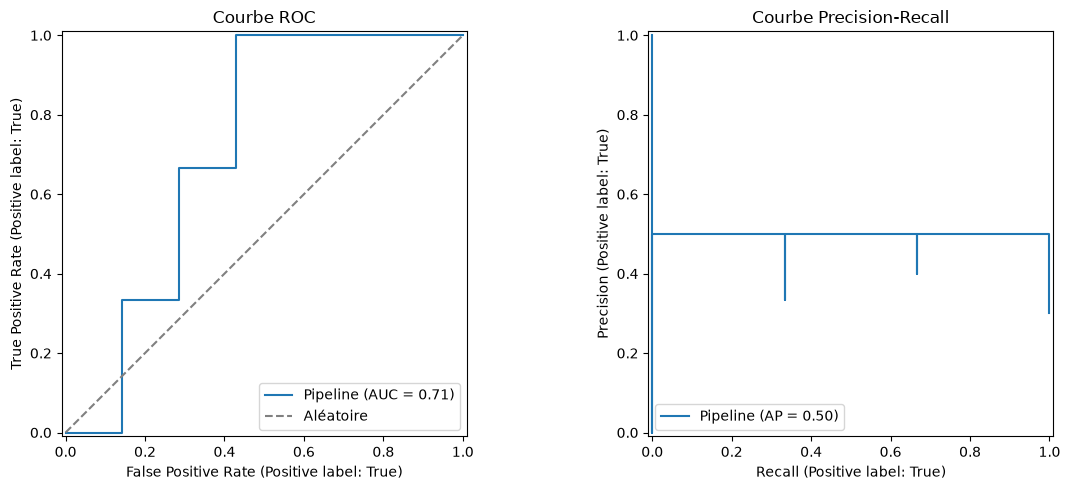

In [750]:
# Affichage des courbes ROC et Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Courbe ROC
RocCurveDisplay.from_estimator(model_fitted, df_test_X, df_test_Y, ax=axes[0])
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aléatoire")
axes[0].set_title("Courbe ROC")
axes[0].legend()

# Courbe Precision-Recall
PrecisionRecallDisplay.from_estimator(model_fitted, df_test_X, df_test_Y, ax=axes[1])
axes[1].set_title("Courbe Precision-Recall")

plt.tight_layout()
plt.show()

'confusion_matrix'

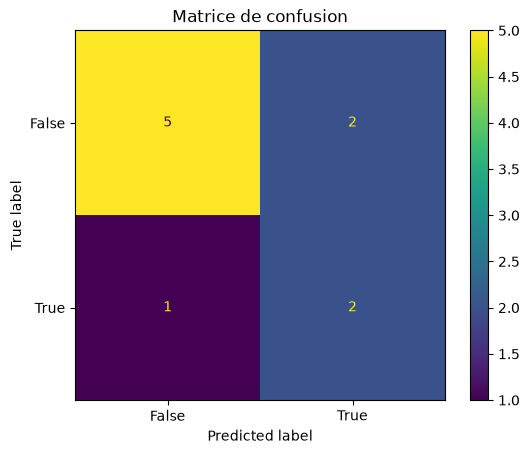

In [751]:
### confusion_matrix
ConfusionMatrixDisplay.from_estimator(
    estimator = model_fitted,
    X = df_test_X,
    y = df_test_Y
).ax_.set_title(
    label = f"Matrice de confusion")

display("confusion_matrix")
plt.show()

### **Enregistrement du modèle**

In [123]:
import joblib

# save
joblib.dump(model_fitted, "model.pkl") 

# # load
# clf2 = joblib.load("model.pkl")

# clf2.predict(X[0:1])

NameError: name 'model_fitted' is not defined

# **TEST**

In [156]:
from pprint import pprint
from numpy import array
import joblib

dict_input: dict = {
    "gender": "Female",
    "age": 0,
    "city": "string",
    "cgpa": 10,
    "degree": "B.Arch",
    "profession": "Architect",
    "profession_hour_daily": 24,
    "profession_pressure": 5,
    "profession_satisfaction": 5,
    "financial_stress": 5,
    "sleep_duration": "Less than 5 hours",
    "dietary_habits": "Healthy",
    "history_family_illness_mental": True,
    "history_thoughts_suicidal": True
}

# test_input = array(df_test_X.iloc[0]).reshape(1,-1)
# test_input = df_test_X.head(1)

pprint(list(dict(dict_input).values()))

test_input: pd.DataFrame = pd.DataFrame(
    data = [list(dict(dict_input).values())],
    columns = list(dict(dict_input).keys()) )

pprint(test_input)

test_model: Pipeline = joblib.load("./estimator/model/model.pkl")
test_model.predict(test_input)

['Female',
 0,
 'string',
 10,
 'B.Arch',
 'Architect',
 24,
 5,
 5,
 5,
 'Less than 5 hours',
 'Healthy',
 True,
 True]
   gender  age    city  cgpa  degree profession  profession_hour_daily  \
0  Female    0  string    10  B.Arch  Architect                     24   

   profession_pressure  profession_satisfaction  financial_stress  \
0                    5                        5                 5   

      sleep_duration dietary_habits  history_family_illness_mental  \
0  Less than 5 hours        Healthy                           True   

   history_thoughts_suicidal  
0                       True  


array([ True])